## setup

In [5]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score, f1_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import random 
import copy

le = LabelEncoder()
batch_size=32
X_list = []
y_list = []
subjects_list = []

fold_results = []
fold_conf_mats = []
num_epochs = 60

for i in range(1, 10):
    Xi = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}.npy").astype(np.float32)
    Xi = Xi[:, None, :, :]

    yi = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}L.npy")

    X_list.append(Xi)
    y_list.append(yi)

    subjects_list.append(np.full(len(yi), i))

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
subjects = np.concatenate(subjects_list, axis=0)

le = LabelEncoder()
y_cv = le.fit_transform(y).astype(np.int64)
X_cv = X.astype(np.float32)

logo = LeaveOneGroupOut()
k = len(np.unique(subjects))


def evaluate(model, X, Y, params, batch_size=64):
    was_training = model.training
    model.eval()

    all_probs = []
    all_preds = []

    with torch.no_grad():
        for s in range(0, len(X), batch_size):
            e = min(s + batch_size, len(X))

            inputs = torch.from_numpy(X[s:e]).float()

            inputs = inputs.cuda(0)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(probs.argmax(dim=1).cpu().numpy())

    probs = np.concatenate(all_probs, axis=0)
    pred_labels = np.concatenate(all_preds, axis=0)


    results = []

    for param in params:
        if param == "acc":
            results.append(accuracy_score(Y, pred_labels))

        elif param == "auc":
            try:
                results.append(
                    roc_auc_score(
                        Y,
                        probs,
                        multi_class="ovo",
                        labels=np.arange(probs.shape[1])
                    )
                )
            except ValueError:
                results.append(None)

        elif param == "fmeasure":
            results.append(f1_score(Y, pred_labels, average="macro"))

    

    if was_training:
        model.train()
    else:
        model.eval()
    return results

In [6]:
#input: (batch, 1, Chans, Samples)

class EEGNetTorch(nn.Module):
    def __init__(self, nb_classes=4, Chans=22, Samples=1001, dropoutRate=0.5, kernLength=125, F1=8, D=2, F2=16, dropoutType="Dropout"):
        super().__init__()

        DropoutLayer = nn.Dropout


        ##################################################Block 1#################################################
        #Conv2D: F1 filters, (1, kernLength) kernel size
        self.conv_temporal = nn.Conv2d(in_channels=1, out_channels=F1,
            kernel_size=(1, kernLength),
            padding="same", bias=False,
        )

        #BatchNormalization
        self.bn1 = nn.BatchNorm2d(F1, eps=1e-3, momentum=0.01)

        # DepthwiseConv2D: kernel size (chans, 1)
        self.conv_spatial = nn.Conv2d(in_channels=F1, out_channels=F1 * D,
            kernel_size=(Chans, 1),
            groups=F1, bias=False,
        )

        self.bn2 = nn.BatchNorm2d(F1 * D, eps=1e-3, momentum=0.01)

        #activation

        self.pool1 = nn.AvgPool2d(kernel_size=(1, 4))

        self.drop1 = DropoutLayer(dropoutRate)

        ##################################################Block 2#################################################

        #SeparableConv2D: (1,16) kernel size
        self.sepConv = nn.Conv2d(in_channels=F1 * D, out_channels=F1 * D,
            kernel_size=(1, 16),
            padding="same",
            groups=F1 * D, bias=False,
        )

        #SeparableConv2D: F2 filters, 
        self.sep_pointwise = nn.Conv2d(in_channels=F1 * D, out_channels=F2,
            kernel_size=(1, 1),
            bias=False,
        )

        self.bn3 = nn.BatchNorm2d(F2, eps=1e-3, momentum=0.01)
        self.pool2 = nn.AvgPool2d(kernel_size=(1, 8))
        self.drop2 = DropoutLayer(dropoutRate)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, Chans, Samples)
            out = self._features(dummy)
            self.flatten_dim = out.flatten(start_dim=1).shape[1]

        self.classifier = nn.Linear(self.flatten_dim, nb_classes)

    def _features(self, x):
        x = self.conv_temporal(x)
        x = self.bn1(x)

        x = self.conv_spatial(x)

        x = self.bn2(x)
        x = F.elu(x)
        x = self.pool1(x)
        x = self.drop1(x)

        x = self.sepConv(x)
        x = self.sep_pointwise(x)
        x = self.bn3(x)
        x = F.elu(x)
        x = self.pool2(x)
        x = self.drop2(x)

        return x

    def forward(self, x):
        x = self._features(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x

In [7]:
def _add_noise(X, noise_level):
    X = X.copy()

    rng = np.random.default_rng(42)
    signal_std = np.std(X)

    noise = rng.normal(
        loc=0,
        scale=noise_level * signal_std,
        size=X.shape
    )
    return X + noise


In [8]:
batch_size = 32
num_epochs = 60
k = 9
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

nb_classes = len(np.unique(y_cv))
Chans = X_cv.shape[2]
Samples = X_cv.shape[3]

params = ["acc", "auc", "fmeasure"]

patience = 15
min_delta = 1e-4
fold_results = []


## both



================ SCALE 0.1 ================


/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/torch/nn/modules/conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1090.)
  return F.conv2d(


Early stopping at epoch 43
[[0.63194444 0.1875     0.0625     0.11805556]
 [0.03472222 0.77777778 0.18055556 0.00694444]
 [0.02083333 0.10416667 0.86805556 0.00694444]
 [0.52083333 0.21527778 0.00694444 0.25694444]]

Fold 1 Final Validation -
{'acc': 0.6336805555555556, 'auc': np.float64(0.8715117026748972), 'fmeasure': 0.6107125597506213}
Early stopping at epoch 34
[[0.18055556 0.43055556 0.23611111 0.15277778]
 [0.10416667 0.61805556 0.22916667 0.04861111]
 [0.16666667 0.40277778 0.375      0.05555556]
 [0.09722222 0.52083333 0.25       0.13194444]]

Fold 2 Final Validation -
{'acc': 0.3263888888888889, 'auc': np.float64(0.603342817644033), 'fmeasure': 0.2994689234201238}
Early stopping at epoch 51
[[0.50694444 0.11111111 0.10416667 0.27777778]
 [0.01388889 0.72222222 0.00694444 0.25694444]
 [0.0625     0.07638889 0.64583333 0.21527778]
 [0.04861111 0.01388889 0.         0.9375    ]]

Fold 3 Final Validation -
{'acc': 0.703125, 'auc': np.float64(0.9217705118312757), 'fmeasure': 0.701

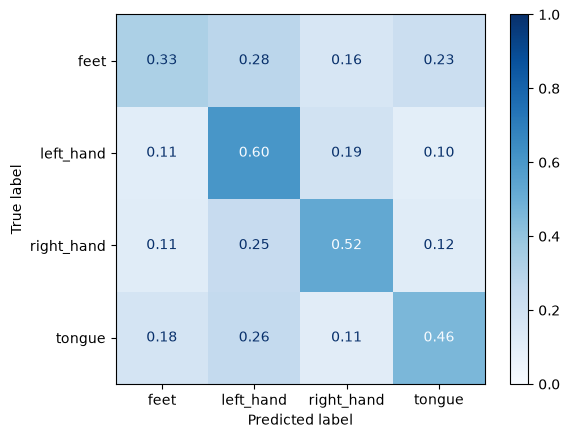



================ SCALE 0.2 ================
Early stopping at epoch 47
[[0.41666667 0.30555556 0.05555556 0.22222222]
 [0.00694444 0.86111111 0.11805556 0.01388889]
 [0.00694444 0.1875     0.79861111 0.00694444]
 [0.36111111 0.26388889 0.         0.375     ]]

Fold 1 Final Validation -
{'acc': 0.6128472222222222, 'auc': np.float64(0.8870482896090536), 'fmeasure': 0.5990799202477671}
Early stopping at epoch 28
[[0.39583333 0.3125     0.18055556 0.11111111]
 [0.28472222 0.5        0.20138889 0.01388889]
 [0.36111111 0.24305556 0.38888889 0.00694444]
 [0.26388889 0.42361111 0.20833333 0.10416667]]

Fold 2 Final Validation -
{'acc': 0.3472222222222222, 'auc': np.float64(0.6277126736111112), 'fmeasure': 0.32706415512419157}
Early stopping at epoch 27
[[0.47222222 0.15277778 0.19444444 0.18055556]
 [0.08333333 0.77777778 0.00694444 0.13194444]
 [0.04861111 0.06944444 0.79166667 0.09027778]
 [0.20833333 0.01388889 0.         0.77777778]]

Fold 3 Final Validation -
{'acc': 0.7048611111111112

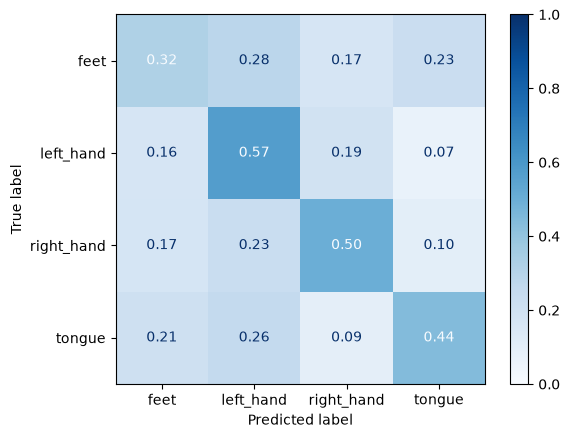



================ SCALE 0.3 ================
[[0.58333333 0.13888889 0.0625     0.21527778]
 [0.04166667 0.78472222 0.15277778 0.02083333]
 [0.02777778 0.13888889 0.82638889 0.00694444]
 [0.50694444 0.1875     0.         0.30555556]]

Fold 1 Final Validation -
{'acc': 0.625, 'auc': np.float64(0.8669785236625515), 'fmeasure': 0.6104666084617684}
Early stopping at epoch 24
[[0.08333333 0.63888889 0.20833333 0.06944444]
 [0.04166667 0.75694444 0.19444444 0.00694444]
 [0.04166667 0.625      0.30555556 0.02777778]
 [0.06944444 0.6875     0.20138889 0.04166667]]

Fold 2 Final Validation -
{'acc': 0.296875, 'auc': np.float64(0.6238948366769548), 'fmeasure': 0.2339496084439905}
Early stopping at epoch 43
[[0.59027778 0.09027778 0.125      0.19444444]
 [0.08333333 0.72222222 0.00694444 0.1875    ]
 [0.15277778 0.03472222 0.65972222 0.15277778]
 [0.16666667 0.01388889 0.         0.81944444]]

Fold 3 Final Validation -
{'acc': 0.6979166666666666, 'auc': np.float64(0.917088638117284), 'fmeasure':

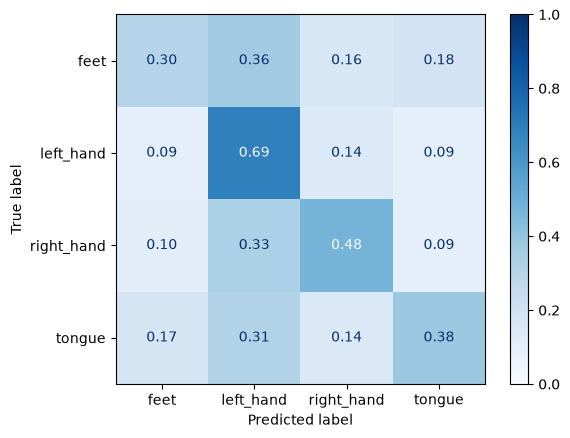



================ SCALE 0.4 ================
[[0.69444444 0.1875     0.0625     0.05555556]
 [0.02083333 0.74305556 0.22916667 0.00694444]
 [0.02083333 0.05555556 0.92361111 0.        ]
 [0.59722222 0.20833333 0.         0.19444444]]

Fold 1 Final Validation -
{'acc': 0.6388888888888888, 'auc': np.float64(0.869530446244856), 'fmeasure': 0.603925337419481}
Early stopping at epoch 33
[[0.33333333 0.25       0.19444444 0.22222222]
 [0.33333333 0.34027778 0.27777778 0.04861111]
 [0.34027778 0.1875     0.41666667 0.05555556]
 [0.30555556 0.25694444 0.28472222 0.15277778]]

Fold 2 Final Validation -
{'acc': 0.3107638888888889, 'auc': np.float64(0.5860178755144033), 'fmeasure': 0.30317965736802016}
Early stopping at epoch 54
[[0.47916667 0.125      0.19444444 0.20138889]
 [0.0625     0.79861111 0.00694444 0.13194444]
 [0.0625     0.06944444 0.6875     0.18055556]
 [0.1875     0.03472222 0.02083333 0.75694444]]

Fold 3 Final Validation -
{'acc': 0.6805555555555556, 'auc': np.float64(0.9140142

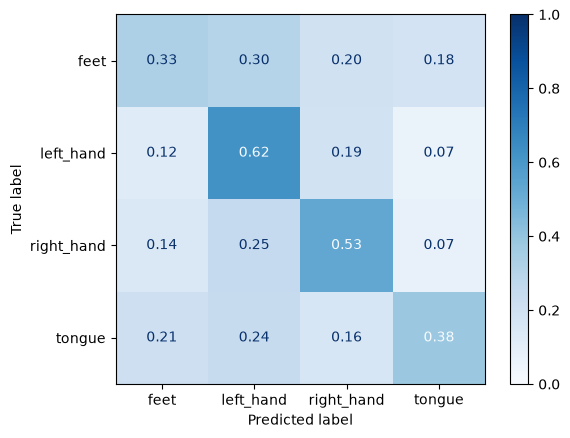

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

scale_results = {}
scale_conf_mats = {}

for scale in [0.1, 0.2, 0.3, 0.4]:

    print(f"\n\n================ SCALE {scale} ================")


    fold_results = []
    fold_conf_mats = []

    for fold, (train_idx, valid_idx) in enumerate(logo.split(X_cv, y_cv, groups=subjects), start=1):

        X_tr = X_cv[train_idx].copy()
        X_va = X_cv[valid_idx].copy()

        y_tr = y_cv[train_idx]
        y_va = y_cv[valid_idx]

        X_tr = _add_noise(X_tr, scale)
        X_va = _add_noise(X_va, scale)

        train_ds = TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.long)
        )

        valid_ds = TensorDataset(
            torch.tensor(X_va, dtype=torch.float32),
            torch.tensor(y_va, dtype=torch.long)
        )

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

        net = EEGNetTorch(
            nb_classes=4,
            Chans=22,
            Samples=1001,
            kernLength=64,
            F1=32,
            D=4,
            F2=16,
            dropoutRate=0.4854763234903182,
        ).to(device)

        optimizer = torch.optim.Adam(
            net.parameters(),
            lr=0.0004102432506048275
        )

        criterion = torch.nn.CrossEntropyLoss()

        best_val_loss = float("inf")
        best_model_state = None
        epochs_without_improvement = 0

        for epoch in range(num_epochs):

            net.train()
            running_loss = 0.0
            n_seen = 0

            for inputs, labels in train_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad(set_to_none=True)
                outputs = net(inputs)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                n_seen += inputs.size(0)

            train_loss = running_loss / n_seen
            #print("Training Loss", train_loss)

            net.eval()
            val_loss = 0.0
            val_seen = 0

            with torch.no_grad():
                for inputs, labels in valid_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * inputs.size(0)
                    val_seen += inputs.size(0)

            val_loss = val_loss / val_seen
            #print("Validation Loss", val_loss)

            #print("Train -", evaluate(net, X_tr, y_tr, params))
            #print("Validation -", evaluate(net, X_va, y_va, params))

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(net.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if best_model_state is not None:
            net.load_state_dict(best_model_state)

        metrics_raw = evaluate(net, X_va, y_va, params)

        if isinstance(metrics_raw, dict):
            metrics = metrics_raw
        else:
            metrics = dict(zip(params, metrics_raw))

        fold_results.append(metrics)

        # Confusion matrix for this fold
        net.eval()
        y_pred = []

        with torch.no_grad():
            X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
            outputs = net(X_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)

        cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3], normalize="true")
        print(cm)
        
        fold_conf_mats.append(cm)

        print(f"\nFold {fold} Final Validation -")
        print(metrics)
        #print("Confusion Matrix:")
        #print(cm)

    print(f"\n========== Scale {scale} Cross-Validation Results ==========")

    avg_metrics = {}

    for metric in params:
        values = [result[metric] for result in fold_results]
        avg_metrics[metric] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
        print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

    avg_cm = np.mean(fold_conf_mats, axis=0)

    
    print("\nAverage Confusion Matrix:")
    print(avg_cm)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=avg_cm,
        display_labels=le.classes_
    )

    disp.plot(
        cmap="Blues",
        im_kw={"vmin": 0, "vmax": 1},
        values_format=".2f"
    )

    plt.show()
    scale_results[scale] = avg_metrics
    scale_conf_mats[scale] = avg_cm

## train



================ SCALE 0.1 ================
Early stopping at epoch 25
[[0.57638889 0.13194444 0.04861111 0.24305556]
 [0.08333333 0.63194444 0.25694444 0.02777778]
 [0.02083333 0.09027778 0.88194444 0.00694444]
 [0.43055556 0.1875     0.00694444 0.375     ]]

Fold 1 Final Validation -
{'acc': 0.6163194444444444, 'auc': np.float64(0.846535011574074), 'fmeasure': 0.6056698078965097}
Early stopping at epoch 21
[[0.13194444 0.49305556 0.17361111 0.20138889]
 [0.06944444 0.71527778 0.15277778 0.0625    ]
 [0.08333333 0.55555556 0.29166667 0.06944444]
 [0.09027778 0.61111111 0.16666667 0.13194444]]

Fold 2 Final Validation -
{'acc': 0.3177083333333333, 'auc': np.float64(0.5907560120884773), 'fmeasure': 0.2806826351083722}
Early stopping at epoch 37
[[0.56944444 0.11111111 0.21527778 0.10416667]
 [0.13888889 0.70833333 0.0625     0.09027778]
 [0.09722222 0.03472222 0.86111111 0.00694444]
 [0.25       0.09027778 0.04166667 0.61805556]]

Fold 3 Final Validation -
{'acc': 0.6892361111111112, 

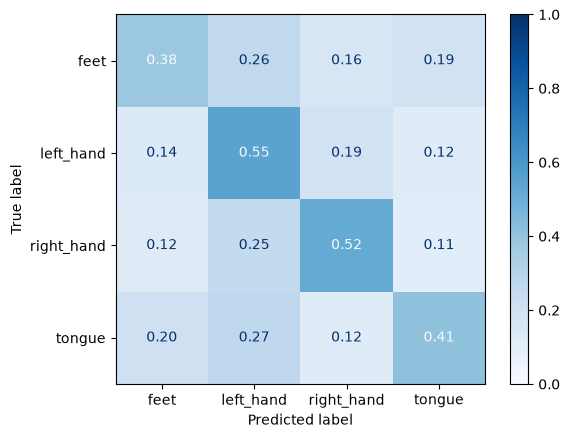



================ SCALE 0.2 ================
[[0.36805556 0.22916667 0.14583333 0.25694444]
 [0.02083333 0.74305556 0.22222222 0.01388889]
 [0.01388889 0.11111111 0.86805556 0.00694444]
 [0.22222222 0.16666667 0.02083333 0.59027778]]

Fold 1 Final Validation -
{'acc': 0.6423611111111112, 'auc': np.float64(0.8684614519032922), 'fmeasure': 0.6286715774014411}
Early stopping at epoch 16
[[0.3125     0.23611111 0.39583333 0.05555556]
 [0.24305556 0.24305556 0.5        0.01388889]
 [0.26388889 0.14583333 0.5625     0.02777778]
 [0.29166667 0.24305556 0.40972222 0.05555556]]

Fold 2 Final Validation -
{'acc': 0.2934027777777778, 'auc': np.float64(0.5666433577674898), 'fmeasure': 0.26122825951384726}
Early stopping at epoch 30
[[0.45833333 0.07638889 0.17361111 0.29166667]
 [0.17361111 0.5625     0.04166667 0.22222222]
 [0.09722222 0.02777778 0.75       0.125     ]
 [0.18055556 0.04166667 0.01388889 0.76388889]]

Fold 3 Final Validation -
{'acc': 0.6336805555555556, 'auc': np.float64(0.87293

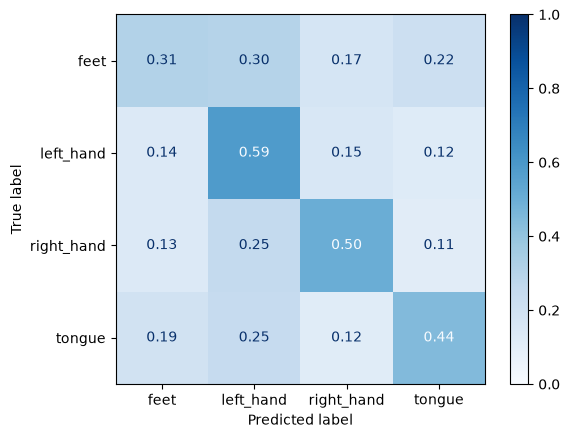



================ SCALE 0.3 ================
Early stopping at epoch 33
[[0.77777778 0.07638889 0.07638889 0.06944444]
 [0.07638889 0.61805556 0.28472222 0.02083333]
 [0.01388889 0.08333333 0.90277778 0.        ]
 [0.73611111 0.10416667 0.00694444 0.15277778]]

Fold 1 Final Validation -
{'acc': 0.6128472222222222, 'auc': np.float64(0.8630561985596709), 'fmeasure': 0.5737692477760203}
Early stopping at epoch 15
[[0.02083333 0.1875     0.64583333 0.14583333]
 [0.03472222 0.29861111 0.64583333 0.02083333]
 [0.01388889 0.14583333 0.81944444 0.02083333]
 [0.04166667 0.22222222 0.66666667 0.06944444]]

Fold 2 Final Validation -
{'acc': 0.3020833333333333, 'auc': np.float64(0.5678811406893004), 'fmeasure': 0.22597953631449474}
Early stopping at epoch 50
[[0.52083333 0.11111111 0.22916667 0.13888889]
 [0.13888889 0.74305556 0.02777778 0.09027778]
 [0.08333333 0.125      0.76388889 0.02777778]
 [0.34027778 0.04166667 0.04861111 0.56944444]]

Fold 3 Final Validation -
{'acc': 0.6493055555555556

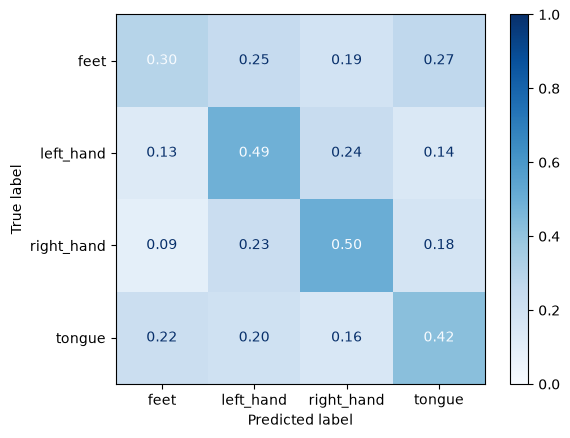



================ SCALE 0.4 ================
Early stopping at epoch 18
[[0.55555556 0.08333333 0.03472222 0.32638889]
 [0.08333333 0.64583333 0.19444444 0.07638889]
 [0.07638889 0.15972222 0.76388889 0.        ]
 [0.34027778 0.08333333 0.         0.57638889]]

Fold 1 Final Validation -
{'acc': 0.6354166666666666, 'auc': np.float64(0.8730910815329218), 'fmeasure': 0.6361191952510725}
Early stopping at epoch 15
[[0.29861111 0.56944444 0.         0.13194444]
 [0.1875     0.72916667 0.01388889 0.06944444]
 [0.25       0.68055556 0.01388889 0.05555556]
 [0.23611111 0.71527778 0.         0.04861111]]

Fold 2 Final Validation -
{'acc': 0.2725694444444444, 'auc': np.float64(0.5425226658950617), 'fmeasure': 0.19976221391178095}
Early stopping at epoch 37
[[0.57638889 0.11805556 0.16666667 0.13888889]
 [0.125      0.74305556 0.00694444 0.125     ]
 [0.14583333 0.15972222 0.60416667 0.09027778]
 [0.1875     0.04861111 0.02083333 0.74305556]]

Fold 3 Final Validation -
{'acc': 0.6666666666666666

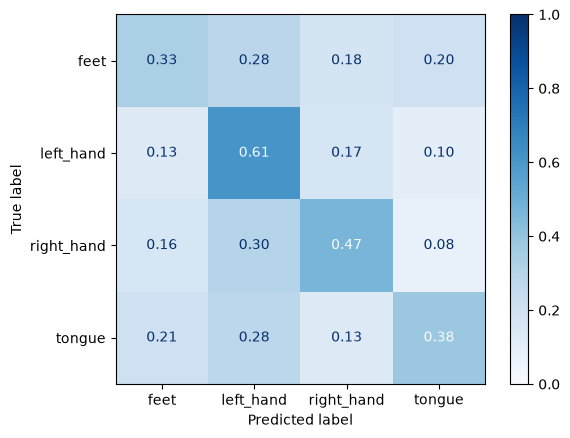

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

scale_results = {}
scale_conf_mats = {}

for scale in [0.1, 0.2, 0.3, 0.4]:

    print(f"\n\n================ SCALE {scale} ================")


    fold_results = []
    fold_conf_mats = []

    for fold, (train_idx, valid_idx) in enumerate(logo.split(X_cv, y_cv, groups=subjects), start=1):

        X_tr = X_cv[train_idx].copy()
        X_va = X_cv[valid_idx].copy()

        y_tr = y_cv[train_idx]
        y_va = y_cv[valid_idx]

        X_tr = _add_noise(X_tr, scale)

        train_ds = TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.long)
        )

        valid_ds = TensorDataset(
            torch.tensor(X_va, dtype=torch.float32),
            torch.tensor(y_va, dtype=torch.long)
        )

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

        net = EEGNetTorch(
        nb_classes=4,
        Chans=22,
        Samples=1001,
        kernLength=250,
        F1=8,
        D=1,
        F2=16,
        dropoutRate=0.25550867989537085,
        ).to(device)

        optimizer = torch.optim.Adam(
            net.parameters(),
            lr=0.0026353430928847833, 
            weight_decay=1.4077242503865625e-06
        )

        criterion = torch.nn.CrossEntropyLoss()

        best_val_loss = float("inf")
        best_model_state = None
        epochs_without_improvement = 0

        for epoch in range(num_epochs):

            net.train()
            running_loss = 0.0
            n_seen = 0

            for inputs, labels in train_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad(set_to_none=True)
                outputs = net(inputs)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                n_seen += inputs.size(0)

            train_loss = running_loss / n_seen
            #print("Training Loss", train_loss)

            net.eval()
            val_loss = 0.0
            val_seen = 0

            with torch.no_grad():
                for inputs, labels in valid_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * inputs.size(0)
                    val_seen += inputs.size(0)

            val_loss = val_loss / val_seen
            #print("Validation Loss", val_loss)

            #print("Train -", evaluate(net, X_tr, y_tr, params))
            #print("Validation -", evaluate(net, X_va, y_va, params))

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(net.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if best_model_state is not None:
            net.load_state_dict(best_model_state)

        metrics_raw = evaluate(net, X_va, y_va, params)

        if isinstance(metrics_raw, dict):
            metrics = metrics_raw
        else:
            metrics = dict(zip(params, metrics_raw))

        fold_results.append(metrics)

        # Confusion matrix for this fold
        net.eval()
        y_pred = []

        with torch.no_grad():
            X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
            outputs = net(X_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)

        cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3], normalize="true")
        print(cm)
        
        fold_conf_mats.append(cm)

        print(f"\nFold {fold} Final Validation -")
        print(metrics)
        #print("Confusion Matrix:")
        #print(cm)

    print(f"\n========== Scale {scale} Cross-Validation Results ==========")

    avg_metrics = {}

    for metric in params:
        values = [result[metric] for result in fold_results]
        avg_metrics[metric] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
        print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

    avg_cm = np.mean(fold_conf_mats, axis=0)

    
    print("\nAverage Confusion Matrix:")
    print(avg_cm)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=avg_cm,
        display_labels=le.classes_
    )

    disp.plot(
        cmap="Blues",
        im_kw={"vmin": 0, "vmax": 1},
        values_format=".2f"
    )

    plt.show()
    scale_results[scale] = avg_metrics
    scale_conf_mats[scale] = avg_cm

## test



================ SCALE 0.1 ================
Early stopping at epoch 38
[[0.59027778 0.1875     0.04861111 0.17361111]
 [0.02083333 0.875      0.09722222 0.00694444]
 [0.04166667 0.1875     0.77083333 0.        ]
 [0.53472222 0.21527778 0.         0.25      ]]

Fold 1 Final Validation -
{'acc': 0.6215277777777778, 'auc': np.float64(0.877805105452675), 'fmeasure': 0.6008510209514675}
Early stopping at epoch 24
[[0.04861111 0.54861111 0.35416667 0.04861111]
 [0.02777778 0.6875     0.28472222 0.        ]
 [0.03472222 0.50694444 0.45138889 0.00694444]
 [0.02083333 0.63194444 0.30555556 0.04166667]]

Fold 2 Final Validation -
{'acc': 0.3072916666666667, 'auc': np.float64(0.6261775012860081), 'fmeasure': 0.23651448481276519}
Early stopping at epoch 33
[[0.40972222 0.10416667 0.18055556 0.30555556]
 [0.04861111 0.75694444 0.00694444 0.1875    ]
 [0.03472222 0.04861111 0.79166667 0.125     ]
 [0.05555556 0.00694444 0.00694444 0.93055556]]

Fold 3 Final Validation -
{'acc': 0.7222222222222222,

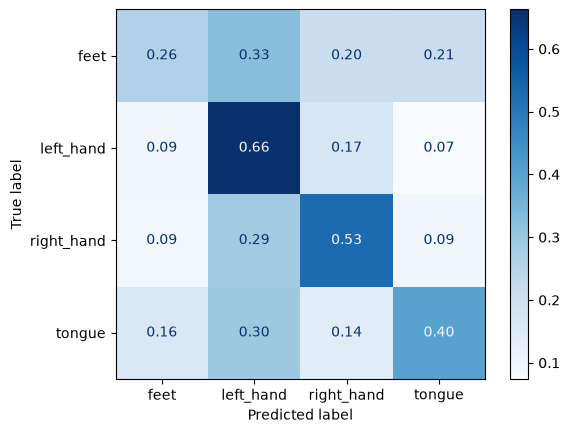



================ SCALE 0.2 ================
[[0.65972222 0.10416667 0.0625     0.17361111]
 [0.01388889 0.78472222 0.19444444 0.00694444]
 [0.02083333 0.09722222 0.875      0.00694444]
 [0.47916667 0.16666667 0.00694444 0.34722222]]

Fold 1 Final Validation -
{'acc': 0.6666666666666666, 'auc': np.float64(0.8812090084876543), 'fmeasure': 0.6516828795056876}
Early stopping at epoch 23
[[0.26388889 0.35416667 0.10416667 0.27777778]
 [0.25694444 0.57638889 0.09722222 0.06944444]
 [0.3125     0.42361111 0.16666667 0.09722222]
 [0.19444444 0.5625     0.08333333 0.15972222]]

Fold 2 Final Validation -
{'acc': 0.2916666666666667, 'auc': np.float64(0.5875188882458848), 'fmeasure': 0.2710778346863422}
Early stopping at epoch 27
[[0.40972222 0.11111111 0.02083333 0.45833333]
 [0.04861111 0.60416667 0.         0.34722222]
 [0.07638889 0.09722222 0.40277778 0.42361111]
 [0.02777778 0.00694444 0.         0.96527778]]

Fold 3 Final Validation -
{'acc': 0.5954861111111112, 'auc': np.float64(0.916755

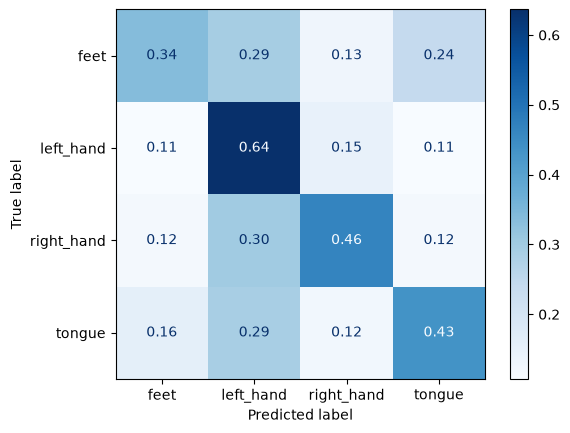



================ SCALE 0.3 ================
[[0.59027778 0.13194444 0.03472222 0.24305556]
 [0.04166667 0.84722222 0.05555556 0.05555556]
 [0.05555556 0.38888889 0.50694444 0.04861111]
 [0.45138889 0.15972222 0.00694444 0.38194444]]

Fold 1 Final Validation -
{'acc': 0.5815972222222222, 'auc': np.float64(0.8543233989197531), 'fmeasure': 0.5740198556463617}
Early stopping at epoch 17
[[0.10416667 0.54861111 0.07638889 0.27083333]
 [0.11805556 0.70138889 0.06944444 0.11111111]
 [0.14583333 0.625      0.09027778 0.13888889]
 [0.11111111 0.68055556 0.03472222 0.17361111]]

Fold 2 Final Validation -
{'acc': 0.2673611111111111, 'auc': np.float64(0.5444155092592592), 'fmeasure': 0.22059271398541522}
Early stopping at epoch 33
[[0.41666667 0.14583333 0.13194444 0.30555556]
 [0.125      0.6875     0.00694444 0.18055556]
 [0.11805556 0.07638889 0.54166667 0.26388889]
 [0.11805556 0.0625     0.00694444 0.8125    ]]

Fold 3 Final Validation -
{'acc': 0.6145833333333334, 'auc': np.float64(0.88163

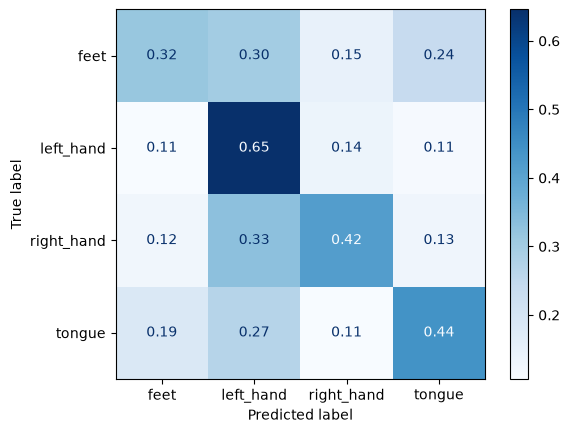



================ SCALE 0.4 ================
[[0.72916667 0.10416667 0.08333333 0.08333333]
 [0.14583333 0.63888889 0.19444444 0.02083333]
 [0.08333333 0.04166667 0.875      0.        ]
 [0.59027778 0.14583333 0.01388889 0.25      ]]

Fold 1 Final Validation -
{'acc': 0.6232638888888888, 'auc': np.float64(0.8636750900205761), 'fmeasure': 0.602750166247216}
Early stopping at epoch 16
[[0.32638889 0.26388889 0.06944444 0.34027778]
 [0.26388889 0.38194444 0.11111111 0.24305556]
 [0.3125     0.375      0.07638889 0.23611111]
 [0.25       0.38888889 0.11111111 0.25      ]]

Fold 2 Final Validation -
{'acc': 0.2586805555555556, 'auc': np.float64(0.5149819958847736), 'fmeasure': 0.24337863836364504}
Early stopping at epoch 46
[[0.48611111 0.16666667 0.25       0.09722222]
 [0.05555556 0.86805556 0.02777778 0.04861111]
 [0.08333333 0.125      0.74305556 0.04861111]
 [0.25       0.09722222 0.08333333 0.56944444]]

Fold 3 Final Validation -
{'acc': 0.6666666666666666, 'auc': np.float64(0.891163

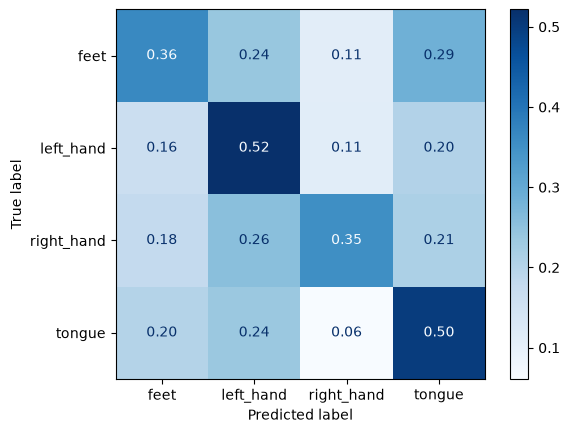

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

scale_results = {}
scale_conf_mats = {}

for scale in [0.1, 0.2, 0.3, 0.4]:

    print(f"\n\n================ SCALE {scale} ================")


    fold_results = []
    fold_conf_mats = []

    for fold, (train_idx, valid_idx) in enumerate(logo.split(X_cv, y_cv, groups=subjects), start=1):

        X_tr = X_cv[train_idx].copy()
        X_va = X_cv[valid_idx].copy()

        y_tr = y_cv[train_idx]
        y_va = y_cv[valid_idx]

        X_va = _add_noise(X_va, scale)

        train_ds = TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.long)
        )

        valid_ds = TensorDataset(
            torch.tensor(X_va, dtype=torch.float32),
            torch.tensor(y_va, dtype=torch.long)
        )

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

        net = EEGNetTorch(
            nb_classes=4,
            Chans=22,
            Samples=1001,
            kernLength=64,
            F1=32,
            D=4,
            F2=16,
            dropoutRate=0.4854763234903182,
        ).to(device)

        optimizer = torch.optim.Adam(
            net.parameters(),
            lr=0.0004102432506048275
        )

        criterion = torch.nn.CrossEntropyLoss()

        best_val_loss = float("inf")
        best_model_state = None
        epochs_without_improvement = 0

        for epoch in range(num_epochs):

            net.train()
            running_loss = 0.0
            n_seen = 0

            for inputs, labels in train_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad(set_to_none=True)
                outputs = net(inputs)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                n_seen += inputs.size(0)

            train_loss = running_loss / n_seen
            #print("Training Loss", train_loss)

            net.eval()
            val_loss = 0.0
            val_seen = 0

            with torch.no_grad():
                for inputs, labels in valid_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * inputs.size(0)
                    val_seen += inputs.size(0)

            val_loss = val_loss / val_seen
            #print("Validation Loss", val_loss)

            #print("Train -", evaluate(net, X_tr, y_tr, params))
            #print("Validation -", evaluate(net, X_va, y_va, params))

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(net.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if best_model_state is not None:
            net.load_state_dict(best_model_state)

        metrics_raw = evaluate(net, X_va, y_va, params)

        if isinstance(metrics_raw, dict):
            metrics = metrics_raw
        else:
            metrics = dict(zip(params, metrics_raw))

        fold_results.append(metrics)

        # Confusion matrix for this fold
        net.eval()
        y_pred = []

        with torch.no_grad():
            X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
            outputs = net(X_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)

        cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3], normalize="true")
        print(cm)
        
        fold_conf_mats.append(cm)

        print(f"\nFold {fold} Final Validation -")
        print(metrics)
        #print("Confusion Matrix:")
        #print(cm)

    print(f"\n========== Scale {scale} Cross-Validation Results ==========")

    avg_metrics = {}

    for metric in params:
        values = [result[metric] for result in fold_results]
        avg_metrics[metric] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
        print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

    avg_cm = np.mean(fold_conf_mats, axis=0)

    
    print("\nAverage Confusion Matrix:")
    print(avg_cm)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=avg_cm,
        display_labels=le.classes_
    )

    disp.plot(
        cmap="Blues",
        values_format=".2f"
    )

    plt.show()
    scale_results[scale] = avg_metrics
    scale_conf_mats[scale] = avg_cm